# Importing the dependencies

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Loading and Cleaning the data

In [2]:
df = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/combined_train_dataset.csv')
df = df.dropna()
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")

Dataset shape: (21740, 127)
Class distribution:
label
S    1400
D    1400
E    1400
F    1400
G    1400
I    1400
K    1400
P    1400
Q    1400
R    1340
A     600
X     600
W     600
V     600
U     600
T     600
N     600
O     600
B     600
M     600
L     600
C     600
Z     600
Name: count, dtype: int64


# Data augmentation

In [3]:
np.random.seed(42)
print("Random seed set to 42 — results will be reproducible")

Random seed set to 42 — results will be reproducible


In [4]:
def augment_dataset(df, n_augments, noise_std=0.01):
    feature_cols = [c for c in df.columns if c != 'label']
    augmented_rows = []

    for _, row in df.iterrows():
        features = row[feature_cols].values.astype(float)
        label = row['label']
        for _ in range(n_augments):
            noise = np.random.normal(0, noise_std, features.shape)
            augmented = features + noise
            augmented_rows.append(list(augmented) + [label])

    aug_df = pd.DataFrame(augmented_rows, columns=df.columns)
    return pd.concat([df, aug_df], ignore_index=True)


# Load merged dataset
df = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/combined_train_dataset.csv')
df = df.dropna()
print(f"Before augmentation: {df.shape}")

# Split by group
non_targeted = ['A','B','C','L','M','N','O','T','U','V','W','X','Z']
targeted     = ['D','E','F','G','I','K','P','Q','R','S']

df_non = df[df['label'].isin(non_targeted)]
df_tgt = df[df['label'].isin(targeted)]

# Non-targeted: 600 × 5 = 3000 each
# Targeted: ~1400 × 2 = 2800 each
# Both land at roughly 3000 — balanced
df_non_aug = augment_dataset(df_non, n_augments=4)
df_tgt_aug = augment_dataset(df_tgt, n_augments=1)

df_augmented = pd.concat([df_non_aug, df_tgt_aug], ignore_index=True)

print(f"After augmentation:  {df_augmented.shape}")

Before augmentation: (21740, 127)
After augmentation:  (66880, 127)


=== Samples per sign after augmentation ===
label
A    3000
B    3000
C    3000
D    2800
E    2800
F    2800
G    2800
I    2800
K    2800
L    3000
M    3000
N    3000
O    3000
P    2800
Q    2800
R    2680
S    2800
T    3000
U    3000
V    3000
W    3000
X    3000
Z    3000
Name: count, dtype: int64

Min: 2680  |  Max: 3000
Ratio (max/min): 1.12x

NaN values: 0

Feature min: -0.4377
Feature max: 0.3055
Values outside -3 to 3 range: 0


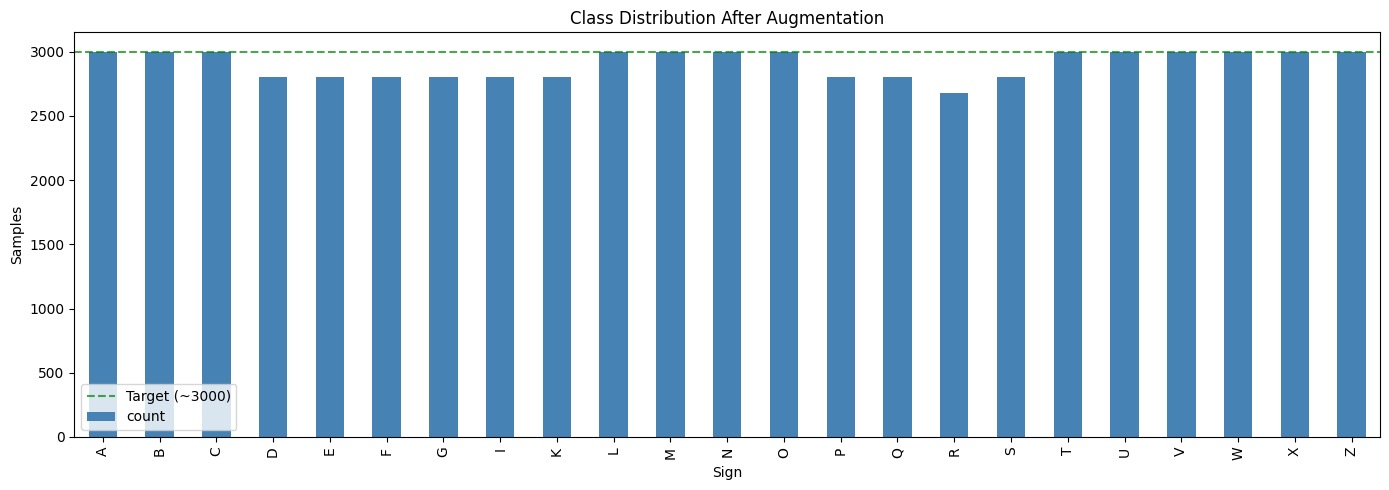


✓ Ready for train/test split


In [5]:
counts = df_augmented['label'].value_counts().sort_index()

print("=== Samples per sign after augmentation ===")
print(counts)
print(f"\nMin: {counts.min()}  |  Max: {counts.max()}")
print(f"Ratio (max/min): {counts.max()/counts.min():.2f}x")

# Any NaN introduced by augmentation
nulls = df_augmented.isnull().sum().sum()
print(f"\nNaN values: {nulls}")

# Feature range check — should still be roughly -1.5 to 1.5
feature_cols = [c for c in df_augmented.columns if c != 'label']
X = df_augmented[feature_cols]
print(f"\nFeature min: {X.min().min():.4f}")
print(f"Feature max: {X.max().max():.4f}")
print(f"Values outside -3 to 3 range: {(X.abs() > 3).sum().sum()}")

# Visual
import matplotlib.pyplot as plt

counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
plt.axhline(y=3000, color='green', linestyle='--',
            label='Target (~3000)', alpha=0.7)
plt.title('Class Distribution After Augmentation')
plt.xlabel('Sign')
plt.ylabel('Samples')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/class_distribution_augmented.png', dpi=150)
plt.show()

print("\n✓ Ready for train/test split")

# Splitting features and labels

In [6]:
X = df_augmented.drop('label', axis=1).values
y = df_augmented['label'].values

# Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 53504 | Test: 13376


# Training Random Forest

In [8]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

Training Random Forest...
=== Random Forest ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           S       1.00      1.00

# Training MLP

In [10]:
print("Training MLP...")
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train, y_train)
mlp_preds = mlp.predict(X_test)
print("=== MLP ===")
print(classification_report(y_test, mlp_preds))

Training MLP...
=== MLP ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           S       1.00      1.00      1.00       560

# Testing on held out test data

In [11]:
df_holdout = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/held_out_dataset.csv')
df_holdout = df_holdout.dropna()

X_holdout = df_holdout.drop('label', axis=1).values
y_holdout = df_holdout['label'].values

holdout_preds = rf.predict(X_holdout)
print("=== Held-Out User (cross-user generalisation) ===")
print(classification_report(y_holdout, holdout_preds))

=== Held-Out User (cross-user generalisation) ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        50
           B       1.00      1.00      1.00        50
           C       0.98      1.00      0.99        50
           D       1.00      1.00      1.00        50
           E       0.94      1.00      0.97        50
           F       1.00      1.00      1.00        50
           G       1.00      1.00      1.00        50
           I       1.00      1.00      1.00        50
           K       1.00      1.00      1.00        50
           L       1.00      1.00      1.00        50
           M       1.00      1.00      1.00        50
           N       0.98      1.00      0.99        50
           O       1.00      1.00      1.00        50
           P       1.00      1.00      1.00        50
           Q       1.00      0.72      0.84        50
           R       0.89      1.00      0.94        50
           S       1.00      0.